# Linear Regression

## Contents

1. Introduction.
2. Dataset Overview.
3. Loss Functions.
4. Linear Regression: Normal Equation.
5. Linear Regression with Gradient Descent.
6. Linear Regression with Scikit-learn.
7. Linear Regression with PyTorch.
8. Comparison and Conclusions.

## 1. Introduction

Suppose we have a set of observations

$$
(x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)
$$

and want to describe the relationship between $x$ and $y$ using a linear function:

$$
\hat{y} = kx + m.
$$

If every observation lies exactly on the same line, its parameters can satisfy

$$
kx_i + m = y_i
$$

for every $i$.

In real data, observations generally do not lie exactly on one line. With more observations than model parameters, the resulting system can be overdetermined and may have no exact solution.

Instead of requiring the model to pass through every point, we can look for a line that approximates the data as closely as possible.

This requires two things:

1. A numerical measure of how far the model predictions are from the observed values.
2. A way to choose model parameters that minimize this error.

The first problem leads to **loss functions**. The second will lead to **linear regression** and methods for estimating its parameters.

## 2. Dataset Overview

The experiment uses the California Housing dataset provided by scikit-learn.

The dataset contains information collected for California census block groups and is used to predict the median house value from demographic, housing, and geographic features.

It contains 20,640 observations with 8 numerical input features and one continuous target.

### 2.1. Loading the Dataset

In [1]:
from sklearn.datasets import fetch_california_housing

In [2]:
dataset = fetch_california_housing()

x = dataset["data"]
y = dataset["target"]

feature_names = dataset["feature_names"]

### 2.2. Features and target

Each row of $x$ represents one California census block group and contains 8 numerical features:

* **MedInc** - Median household income in the block group.
* **HouseAge** - Median house age in the block group.
* **AveRooms** - Average number of rooms per household.
* **AveBedrms** - Average number of bedrooms per household.
* **Population** - Population of the block group.
* **AveOccup** - Average number of household members.
* **Latitude** - Latitude of the block group.
* **Longitude** - Longitude of the block group.

The target $y$ is the **median house value** for the corresponding block group, expressed in units of $100,000.

Therefore,

$$
x \in \mathbb{R}^{20640 \times 8},
\qquad
y \in \mathbb{R}^{20640}.
$$

In [3]:
print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")
print(f"features: {feature_names}")

x shape: (20640, 8)
y shape: (20640,)
features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### 2.3 Feature-Target Relationships

Before fitting a linear regression model, we first inspect the relationship between each input feature and the target.

A linear model represents the prediction as a weighted sum of input features, so these plots provide a first indication of which relationships appear approximately linear and which may be more difficult for a linear model to represent.

They also allow us to inspect feature ranges and identify unusual observations before any preprocessing is applied.

In [4]:
import matplotlib.pyplot as plt
import numpy as np

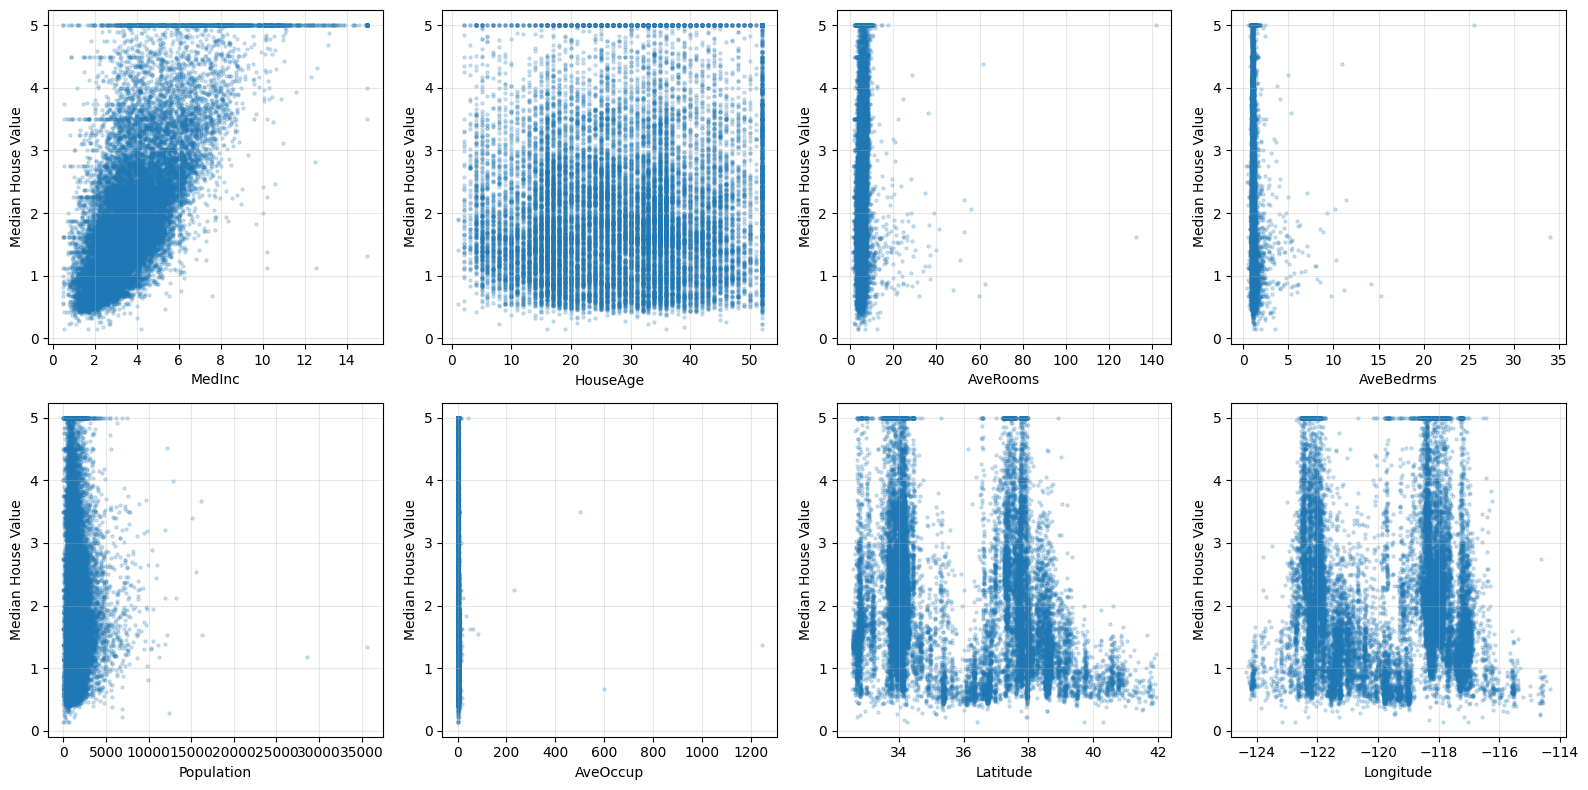

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (ax, feature_name) in enumerate(zip(axes.flat, feature_names)):
    ax.scatter(x[:, i], y, s=5, alpha=0.2)
    ax.set_xlabel(feature_name)
    ax.set_ylabel("Median House Value")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Several properties of the dataset are immediately visible:

* **MedInc** shows the clearest positive and approximately linear relationship with median house value.
* **HouseAge** does not show a clear linear relationship with the target.
* **AveRooms**, **AveBedrms**, **Population**, and especially **AveOccup** contain extreme values that stretch the x-axis and compress most observations into a narrow region.
* **Latitude** and **Longitude** show structured but clearly non-linear relationships with the target.
* The input features also operate on substantially different numerical scales.

At this point, the extreme values make several feature-target relationships difficult to inspect. Before making conclusions about those features, we need a closer view of the region containing most observations.

#### 2.3.1. Central Feature Ranges

The initial plots show that a small number of extreme feature values strongly affect the visualization scale.

To inspect the main concentration of observations without modifying the dataset, the x-axis of each plot is limited to the **1st–99th percentile range** of the corresponding feature.

Only the displayed range is changed. The observations themselves are not filtered, and the original $x$ and $y$ arrays remain unchanged.


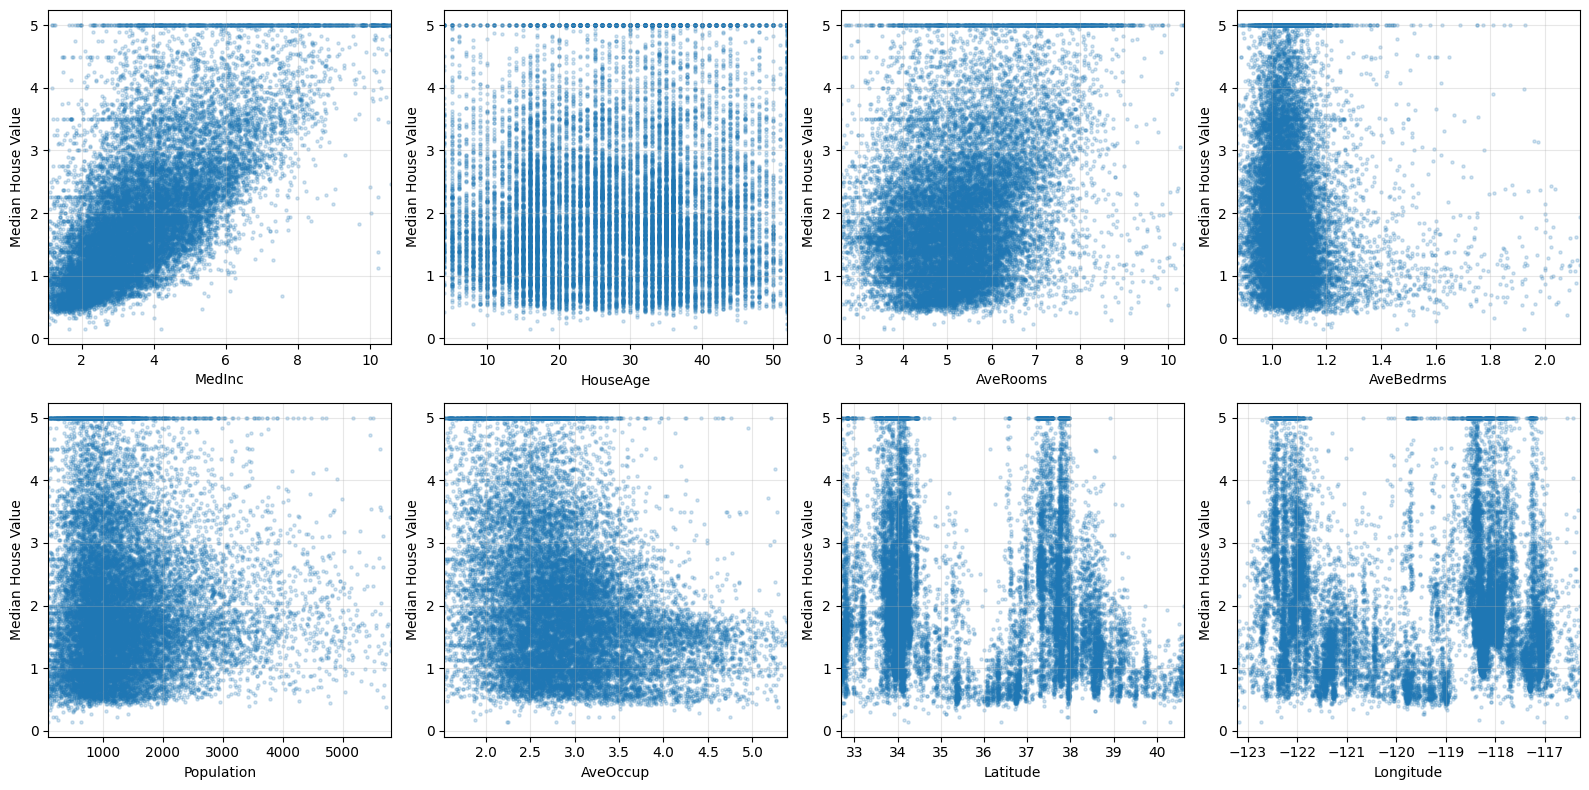

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (ax, feature_name) in enumerate(zip(axes.flat, feature_names)):
    feature = x[:, i]

    ax.scatter(feature, y, s=5, alpha=0.2)

    lower = np.percentile(feature, 1)
    upper = np.percentile(feature, 99)

    ax.set_xlim(lower, upper)

    ax.set_xlabel(feature_name)
    ax.set_ylabel("Median House Value")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The central ranges make the main feature-target relationships easier to inspect:

* **MedInc** remains the strongest approximately linear predictor of median house value.
* **HouseAge** shows variation in the target across its range, but no clear global linear trend.
* **AveRooms** shows some positive association with the target, although the relationship is much weaker and more dispersed than for `MedInc`.
* **AveBedrms**, **Population**, and **AveOccup** do not show strong global linear relationships.
* **Latitude** and **Longitude** reveal pronounced structure, but their relationships with the target are clearly non-linear.

The zoomed plots confirm that the dataset contains a mixture of approximately linear and non-linear relationships.

They also show that some features contain extreme values that may become important later when comparing optimization methods, particularly gradient descent.

#### 2.3.2. Geographic Relationship

The individual plots for `Latitude` and `Longitude` show strong structure, but neither coordinate has a simple one-dimensional relationship with house value.

Unlike the other features, these two variables describe different components of the **same property: geographic location**.

Analyzing them independently therefore loses important spatial information. To inspect this relationship more naturally, we plot longitude and latitude together and use the target value as the color of each observation.


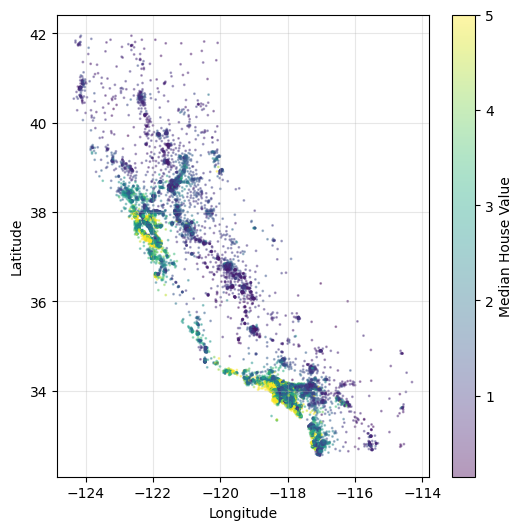

In [7]:
plt.figure(figsize=(6, 6))

scatter = plt.scatter(
    x[:, 7],
    x[:, 6],
    c=y,
    s=1,
    alpha=0.4,
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(scatter, label="Median House Value")
plt.grid(alpha=0.3)

plt.show()

The joint plot reveals a clear spatial structure in median house values.

Nearby census block groups often have similar target values, while different geographic regions show substantially different housing prices. This structure was not visible when latitude and longitude were considered independently.

For linear regression, this is an important limitation of the input representation. The model can learn separate coefficients for latitude and longitude,

$$
w_{\text{lat}}x_{\text{lat}}
+
w_{\text{lon}}x_{\text{lon}},
$$

but this represents only a linear geographic trend. It cannot directly model complex local spatial patterns visible in the data.

This suggests that geographic features may contribute useful information while still being only partially representable by a simple linear model.


### 2.4. Target Distribution

The previous plots describe the relationship between the input features and the target. Before fitting the model, it is also useful to inspect the target itself.

Its distribution can reveal asymmetry, unusual concentrations of observations, or boundaries that may later help explain prediction errors and residuals.

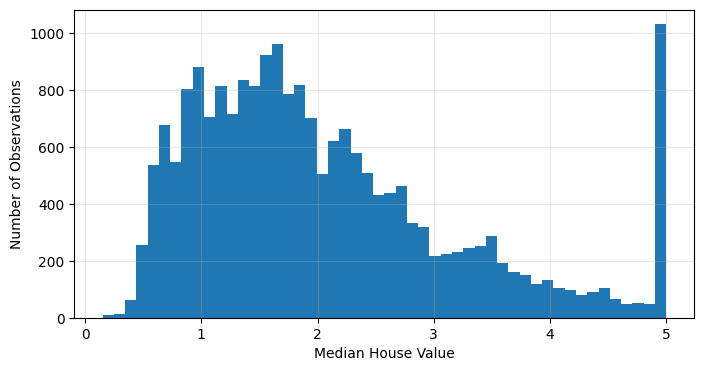

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(y, bins=50)
plt.xlabel("Median House Value")
plt.ylabel("Number of Observations")
plt.grid(alpha=0.3)

plt.show()

The target distribution has two notable properties.

First, the main distribution is **right-skewed**: most census block groups have lower or medium median house values, while progressively fewer observations appear toward the higher-value range.

Second, there is an unusually large concentration of observations at the upper boundary of the target. Rather than forming a continuous tail, many high-value observations accumulate near the maximum recorded value. This indicates a **ceiling effect** in the dataset.

A non-symmetric target distribution does not prevent linear regression from being applied. Linear regression does not require the target variable itself to follow a normal distribution.

However, both the skewed distribution and the concentration near the upper boundary may affect how prediction errors are distributed. We will therefore return to these observations after training when analyzing predictions and residuals.


### 2.5. Observations Before Modeling

The initial data inspection highlights several properties that may affect linear regression:

* Some features, especially `MedInc`, show approximately linear relationships with the target.
* Several other feature-target relationships are weak or clearly non-linear.
* Geographic information has a strong spatial structure that cannot be fully represented by independent linear latitude and longitude terms.
* Some input features contain extreme values and operate on substantially different numerical scales.
* The target distribution is right-skewed and contains a strong concentration at its upper boundary.

No observations are removed and no feature scaling is applied at this stage.

The first models will be trained on the original data. These observations will later help explain model performance, residual patterns, and differences between analytical and gradient-based optimization.

## 3. Loss functions

For a single observation, the difference between the true value and the model prediction is called the **residual**:

$$
e_i = y_i - \hat{y}_i.
$$

For the linear model

$$
\hat{y}_i = kx_i + m,
$$

the residual is

$$
e_i = y_i - (kx_i + m).
$$

For all observations, residuals can be written in matrix form:

$$
\mathbf{e} = \mathbf{y} - X\mathbf{w},
$$

where

$$
\mathbf{y} =
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix},
\qquad
X =
\begin{bmatrix}
x_1 & 1 \\
x_2 & 1 \\
\vdots & \vdots \\
x_n & 1
\end{bmatrix},
\qquad
\mathbf{w} =
\begin{bmatrix}
k \\
m
\end{bmatrix}.
$$

Simply summing residuals does not provide a useful measure of model error because positive and negative residuals can cancel each other out.

Two common ways to avoid this are to use their absolute values or their squares.

### 3.1. Mean Absolute Error

The **Mean Absolute Error (MAE)** is

$$
\operatorname{MAE}
=
\frac{1}{n}
\sum_{i=1}^{n}
|e_i|.
$$

Using the $L_1$ norm:

$$
\operatorname{MAE}
=
\frac{1}{n}
\|\mathbf{e}\|_1.
$$

### 3.2. Mean Squared Error

The **Mean Squared Error (MSE)** is

$$
\operatorname{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}
e_i^2.
$$

Using the $L_2$ norm:

$$
\operatorname{MSE}
=
\frac{1}{n}
\|\mathbf{e}\|_2^2.
$$

Since

$$
\mathbf{e} = \mathbf{y} - X\mathbf{w},
$$

the MSE can be written directly as a function of the model parameters:

$$
\operatorname{MSE}(\mathbf{w})
=
\frac{1}{n}
\|\mathbf{y} - X\mathbf{w}\|_2^2.
$$

The regression problem can therefore be formulated as finding the parameters $\mathbf{w}$ that minimize the loss.

In the next section, we will use MSE to derive these parameters analytically.

## 4. Linear Regression: Normal Equation

We now want to find the parameters of the linear model that minimize the Mean Squared Error.

For a single feature, the model is

$$
\hat{y}_i = kx_i + m.
$$

The MSE therefore becomes a function of the model parameters:

$$
\operatorname{MSE}(k,m)
=
\frac{1}{n}
\sum_{i=1}^{n}
\left(y_i-kx_i-m\right)^2.
$$

The optimal parameters are the values at which this function reaches its minimum:

$$
k^*,m^*
=
\operatorname*{arg\,min}_{k,m}
\operatorname{MSE}(k,m).
$$

### 4.1. Gradient of MSE

To find the minimum analytically, first calculate the partial derivatives of MSE with respect to both model parameters.

For $k$:

$$
\frac{\partial \operatorname{MSE}}{\partial k}
=
\frac{1}{n}
\sum_{i=1}^{n}
\frac{\partial}{\partial k}
\left(y_i-kx_i-m\right)^2.
$$

Applying the chain rule:

$$
\frac{\partial}{\partial k}
\left(y_i-kx_i-m\right)^2
=
-2x_i\left(y_i-kx_i-m\right).
$$

Therefore,

$$
\frac{\partial \operatorname{MSE}}{\partial k}
=
-\frac{2}{n}
\sum_{i=1}^{n}
x_i\left(y_i-\hat{y}_i\right).
$$

Similarly, for $m$:

$$
\frac{\partial}{\partial m}
\left(y_i-kx_i-m\right)^2
=
-2\left(y_i-kx_i-m\right),
$$

and

$$
\frac{\partial \operatorname{MSE}}{\partial m}
=
-\frac{2}{n}
\sum_{i=1}^{n}
\left(y_i-\hat{y}_i\right).
$$

Combining both partial derivatives gives the gradient:

$$
\nabla \operatorname{MSE}(k,m)
=
-\frac{2}{n}
\begin{bmatrix}
\displaystyle\sum_{i=1}^{n}x_i(y_i-\hat{y}_i)
\\[6pt]
\displaystyle\sum_{i=1}^{n}(y_i-\hat{y}_i)
\end{bmatrix}.
$$


### 4.2. Matrix form

Using the design matrix

$$
X=
\begin{bmatrix}
x_1 & 1 \\
x_2 & 1 \\
\vdots & \vdots \\
x_n & 1
\end{bmatrix},
\qquad
\mathbf{w}
=
\begin{bmatrix}
k \\
m
\end{bmatrix},
$$

the predictions for all observations are

$$
\hat{\mathbf{y}}=X\mathbf{w}.
$$

The MSE can therefore be written as

$$
\operatorname{MSE}(\mathbf{w})
=
\frac{1}{n}
\left\|
\mathbf{y}-X\mathbf{w}
\right\|_2^2.
$$

The gradient from the previous section can now be written compactly as

$$
\nabla \operatorname{MSE}(\mathbf{w})
=
\frac{2}{n}
X^T
\left(
X\mathbf{w}-\mathbf{y}
\right).
$$

This representation also works for multiple input features. In the general case,

$$
X\in\mathbb{R}^{n\times(p+1)},
\qquad
\mathbf{w}\in\mathbb{R}^{p+1},
\qquad
\mathbf{y}\in\mathbb{R}^{n},
$$

where $p$ is the number of input features and the additional column of ones accounts for the intercept.


### 4.3. Normal Equation

At the minimum of MSE, its gradient is zero:

$$
\nabla \operatorname{MSE}(\mathbf{w})=0.
$$

Substituting the matrix form of the gradient:

$$
\frac{2}{n}
X^T
\left(
X\mathbf{w}-\mathbf{y}
\right)
=
0.
$$

The constant factor $\frac{2}{n}$ does not affect the solution, so

$$
X^T
\left(
X\mathbf{w}-\mathbf{y}
\right)
=
0.
$$

Expanding the expression:

$$
X^TX\mathbf{w}-X^T\mathbf{y}=0.
$$

Therefore,

$$
X^TX\mathbf{w}=X^T\mathbf{y}.
$$

This is the **normal equation**.

If $X^TX$ is invertible, multiply both sides by $(X^TX)^{-1}$:

$$
\boxed{
\mathbf{w}
=
(X^TX)^{-1}X^T\mathbf{y}
}
$$

This gives the model parameters that minimize the Mean Squared Error without iterative optimization.

The next implementation will calculate these parameters directly with NumPy.

### 4.4. NumPy implementation

In [9]:
x = dataset["data"]
y = dataset["target"].reshape(-1, 1)